In [1]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load dataset
df = pd.read_csv("public-transport-madrid.csv")

# Display first rows
df.head()

,date,metro,bus,road,train,total
0,2023-01-01,685684,319488,155714,174991,1335877
1,2023-01-02,1581661,1024836,588003,446467,3640967
2,2023-01-03,1781186,1151845,662751,510268,4106050
3,2023-01-04,1846531,1160892,681347,517539,4206309
4,2023-01-05,1842966,1087828,615698,487856,4034348


In [3]:
# Dataset information
df.info()

# Check missing values
df.isnull().sum()

# Summary statistics
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 715 entries, 0 to 714
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   date    715 non-null    str  
 1   metro   715 non-null    int64
 2   bus     715 non-null    int64
 3   road    715 non-null    int64
 4   train   715 non-null    int64
 5   total   715 non-null    int64
dtypes: int64(5), str(1)
memory usage: 40.6 KB


,metro,bus,road,train,total
count,7.150000e+02,7.150000e+02,7.150000e+02,715.000000,7.150000e+02
mean,1.883798e+06,1.274766e+06,7.844724e+05,510511.139860,4.453548e+06
std,5.022440e+05,4.212405e+05,2.911433e+05,144870.763319,1.345766e+06
min,6.694940e+05,3.194880e+05,1.557140e+05,174991.000000,1.335877e+06
25%,1.436912e+06,8.928350e+05,4.981055e+05,373921.500000,3.231437e+06
50%,2.047048e+06,1.440163e+06,8.808320e+05,572224.000000,4.981458e+06
75%,2.308936e+06,1.669680e+06,1.050462e+06,635579.000000,5.653856e+06
max,2.765509e+06,1.834307e+06,1.274325e+06,743435.000000,6.382987e+06


In [4]:
# Drop rows with missing values (optional depending on dataset)
df = df.dropna()

# Convert categorical columns if necessary
df = pd.get_dummies(df, drop_first=True)

# Separate features
X = df.drop(columns=[df.columns[-1]])  # assuming last column is target
y = df[df.columns[-1]]

In [5]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [6]:
# Choose number of clusters
kmeans = KMeans(n_clusters=3, random_state=42)

# Fit model
clusters = kmeans.fit_predict(X_scaled)

# Add cluster labels to dataframe
df['Cluster'] = clusters

df.head()

,metro,bus,road,train,total,date_2023-01-02,date_2023-01-03,date_2023-01-04,date_2023-01-05,date_2023-01-06,...,date_2024-12-07,date_2024-12-08,date_2024-12-09,date_2024-12-10,date_2024-12-11,date_2024-12-12,date_2024-12-13,date_2024-12-14,date_2024-12-15,Cluster
0,685684,319488,155714,174991,1335877,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,1
1,1581661,1024836,588003,446467,3640967,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,2
2,1781186,1151845,662751,510268,4106050,False,True,False,False,False,...,False,False,False,False,False,False,False,False,False,2
3,1846531,1160892,681347,517539,4206309,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,2
4,1842966,1087828,615698,487856,4034348,False,False,False,True,False,...,False,False,False,False,False,False,False,False,False,2


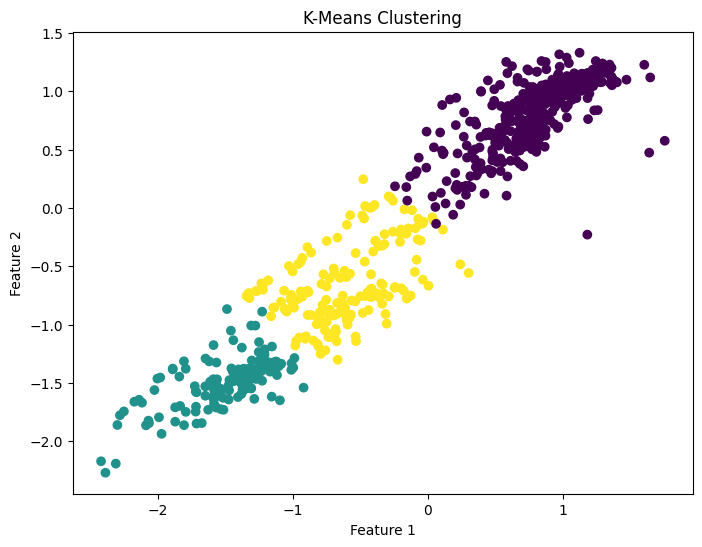

In [7]:
plt.figure(figsize=(8,6))

plt.scatter(X_scaled[:,0], X_scaled[:,1],
            c=clusters, cmap='viridis')

plt.title("K-Means Clustering")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

In [9]:
model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [10]:
y_pred = model.predict(X_test)

In [12]:
print("y_test unique:", set(y_test))
print("y_pred unique:", set(y_pred))

y_test unique: {False}
y_pred unique: {np.False_}


In [14]:
import numpy as np

print("y distribution:", np.bincount(y))

y distribution: [714   1]
